# LIBRARIES

In [75]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels

In [76]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# 1. Loading, converting and cleaning of the data

## MARKET TEMPERATURE DATASET

In [77]:
df_market_temp = pd.read_csv("dataset/Market_temp_index_uc_month.csv")

In [78]:
df_market_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0
1,394913,1,"New York, NY",msa,NY,53.0,52.0,55.0,57.0,56.0,...,92.0,90.0,87.0,81.0,78.0,77.0,77.0,74.0,71.0,71.0
2,753899,2,"Los Angeles, CA",msa,CA,69.0,66.0,66.0,67.0,66.0,...,85.0,83.0,80.0,74.0,71.0,67.0,65.0,63.0,62.0,63.0
3,394463,3,"Chicago, IL",msa,IL,48.0,49.0,51.0,52.0,51.0,...,74.0,76.0,75.0,71.0,67.0,64.0,61.0,58.0,56.0,56.0
4,394514,4,"Dallas, TX",msa,TX,55.0,55.0,58.0,60.0,59.0,...,67.0,67.0,64.0,59.0,55.0,52.0,49.0,48.0,49.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,753929,935,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,39.0,36.0,27.0,40.0,53.0,47.0,31.0,34.0,42.0,41.0
924,394743,936,"Ketchikan, AK",msa,AK,37.0,35.0,34.0,37.0,49.0,...,74.0,69.0,49.0,53.0,61.0,66.0,57.0,53.0,44.0,50.0
925,753874,937,"Craig, CO",msa,CO,3.0,23.0,52.0,67.0,56.0,...,61.0,55.0,59.0,57.0,48.0,33.0,21.0,28.0,41.0,37.0
926,395188,938,"Vernon, TX",msa,TX,51.0,45.0,NaN,48.0,65.0,...,83.0,78.0,64.0,65.0,61.0,52.0,57.0,56.0,51.0,43.0


We can see that market temperature dataset has 928 rows and 88 columns. First 5 columns are:

- ***RegionID:*** Unique identifier. Each US region has an id. 102001 is United States id, not a specific country. There 928 different IDs, except 102001, all other corrispond to a specific region. 
- ***SizeRank:*** Ranking of the region from most populated to the less populated. SizeRank has 925 different values. It means that some of countries have the same rank. They are not NaN values (except United States obviously), I won't "fix" it since it is not a specific region.
- ***RegionName:*** Associates a name to id number. 928 different Region names obviously. 
- ***RegionType:*** 2 different types of regions:
    - **country:** Since we have a row about the United States, here the country is only for US. 
    - **msa:** Metropolitan Statistical Area (all 927 remaining rows).
- ***StateName:*** The name of each state (US of course is NaN)


**Date columns:**<br>
As we can see the other 83 remaining columnns are dates. Pandas sees those dates as a column name (string) not a date sequence. So, I need to transform them to do time series analysis. 

In [79]:
df_market_temp['RegionID'].count()


np.int64(928)

In [80]:
len(df_market_temp['SizeRank'].unique())

925

In [81]:
df_market_temp.isnull().sum()

RegionID       0
SizeRank       0
RegionName     0
RegionType     0
StateName      1
              ..
2024-07-31     1
2024-08-31     5
2024-09-30     7
2024-10-31     8
2024-11-30    13
Length: 88, dtype: int64

In [82]:
len(df_market_temp['RegionName'].unique())

928

In [83]:
df_market_temp['RegionType'].unique()

array(['country', 'msa'], dtype=object)

In [84]:
df_market_temp[df_market_temp['RegionType']=='country']

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0


In [85]:
len(df_market_temp[df_market_temp['RegionType']=='msa'])

927

In [86]:
df_market_temp['StateName'].isnull().sum()

np.int64(1)

### Reshaping the dataset

As we can see the other 83 remaining columnns are dates. Pandas sees those dates as a column name (string) not a date sequence. So, I need to transform them to do time series analysis. 

I use pandas melt function for this operation

In [87]:
df_market_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0
1,394913,1,"New York, NY",msa,NY,53.0,52.0,55.0,57.0,56.0,...,92.0,90.0,87.0,81.0,78.0,77.0,77.0,74.0,71.0,71.0
2,753899,2,"Los Angeles, CA",msa,CA,69.0,66.0,66.0,67.0,66.0,...,85.0,83.0,80.0,74.0,71.0,67.0,65.0,63.0,62.0,63.0
3,394463,3,"Chicago, IL",msa,IL,48.0,49.0,51.0,52.0,51.0,...,74.0,76.0,75.0,71.0,67.0,64.0,61.0,58.0,56.0,56.0
4,394514,4,"Dallas, TX",msa,TX,55.0,55.0,58.0,60.0,59.0,...,67.0,67.0,64.0,59.0,55.0,52.0,49.0,48.0,49.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,753929,935,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,39.0,36.0,27.0,40.0,53.0,47.0,31.0,34.0,42.0,41.0
924,394743,936,"Ketchikan, AK",msa,AK,37.0,35.0,34.0,37.0,49.0,...,74.0,69.0,49.0,53.0,61.0,66.0,57.0,53.0,44.0,50.0
925,753874,937,"Craig, CO",msa,CO,3.0,23.0,52.0,67.0,56.0,...,61.0,55.0,59.0,57.0,48.0,33.0,21.0,28.0,41.0,37.0
926,395188,938,"Vernon, TX",msa,TX,51.0,45.0,NaN,48.0,65.0,...,83.0,78.0,64.0,65.0,61.0,52.0,57.0,56.0,51.0,43.0


In [88]:
df_market_temp_updated = df_market_temp.copy()

# pivoting all date columns into rows
df_market_temp_updated = pd.melt(
    df_market_temp,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], # keep the columns as they are
    var_name='Date',           # the new column that holds dates that were columns
    value_name='MarketTemperature'  # the new column that holds the temperature values, now we have 88 rows for each date and we can see the temperature 
                                    # values here  not like first version that for each region there were 88 columns that holds these temperatures. 
)

# convert columns into pandas timestamp 
df_market_temp_updated['Date'] = pd.to_datetime(df_market_temp_updated['Date'])

# make Date the row index, not just a regular column
df_market_temp_updated.set_index('Date', inplace=True)

In [89]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [90]:
df_market_temp_updated.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'MarketTemperature'],
      dtype='object')

In [91]:
df_market_temp_updated.index

DatetimeIndex(['2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31',
               ...
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30'],
              dtype='datetime64[ns]', name='Date', length=77024, freq=None)

In [92]:
len(df_market_temp_updated.index.unique())

83

### Market temprature index data cleaning:

- missing values: 
    - in *StateName* there are 83 missing values, but we already know that the United State has a row by its own but don't have anything in StateName, after checking I saw that there is no any region with state name "US" or "us" so instead of deleting United States from the table I will just add "US" as its StateName. 
    - There are other missing values in the *MarketTemperature* column. But, here the problem is not easy as in the StateName. So, I will use ***forward fill - ffill*** method that we saw during the lecture. Since pandas scan each column from top to bottom (earliest date to latest date) the index moves in chronological order and when it hits a NaN, ffill method looks backwards and copies the last known real value. The problem with this method can be the very first value is NaN, in that case I can use ***bfill*** method, which propagates the next known valid value backward to replace missing values.

In [93]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName              83
MarketTemperature    2220
dtype: int64

In [94]:
df_market_temp_updated['StateName'].isnull()

Date
2018-01-31     True
2018-01-31    False
2018-01-31    False
2018-01-31    False
2018-01-31    False
              ...  
2024-11-30    False
2024-11-30    False
2024-11-30    False
2024-11-30    False
2024-11-30    False
Name: StateName, Length: 77024, dtype: bool

In [95]:
df_market_temp_updated[
    df_market_temp_updated['StateName'].isna() |
    (df_market_temp_updated['StateName'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-02-28,102001,0,United States,country,NaN,50.0
2018-03-31,102001,0,United States,country,NaN,52.0
2018-04-30,102001,0,United States,country,NaN,54.0
2018-05-31,102001,0,United States,country,NaN,55.0
...,...,...,...,...,...,...
2024-07-31,102001,0,United States,country,NaN,55.0
2024-08-31,102001,0,United States,country,NaN,53.0
2024-09-30,102001,0,United States,country,NaN,52.0


In [96]:
df_market_temp_updated[df_market_temp_updated['StateName']=="us"]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,


In [97]:
df_market_temp_updated['StateName'] = df_market_temp_updated['StateName'].fillna('US')

In [98]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName               0
MarketTemperature    2220
dtype: int64

In [99]:
df_market_temp_updated[
    df_market_temp_updated['MarketTemperature'].isna() |
    (df_market_temp_updated['MarketTemperature'] == 'NaN')
]


,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,786258,483,"Fort Payne, AL",msa,AL,NaN
2018-01-31,845162,535,"Granbury, TX",msa,TX,NaN
2018-01-31,786250,595,"Alexander City, AL",msa,AL,NaN
2018-01-31,394538,596,"Douglas, GA",msa,GA,NaN
2018-01-31,394987,635,"Plymouth, IN",msa,IN,NaN
...,...,...,...,...,...,...
2024-11-30,394947,762,"Ottumwa, IA",msa,IA,NaN
2024-11-30,394331,774,"Angola, IN",msa,IN,NaN
2024-11-30,394777,776,"Laurinburg, NC",msa,NC,NaN


Market temperature missing values fix

In [100]:
# sort first so ffill travels in chronological order
df_market_temp_updated = df_market_temp_updated.sort_index()

df_market_temp_updated['MarketTemperature'] = (
    df_market_temp_updated.groupby('StateName')['MarketTemperature'] # Grouping is important to avoid that first NaN value of a state uses the last value of previous state.
    .ffill()   # fill gaps using last known value within same state
    .bfill()   # catch any NaNs at the very start of a state's history
)

print(df_market_temp_updated['MarketTemperature'].isna().sum())  

0


In [101]:
df_market_temp_updated.isnull().sum()

RegionID             0
SizeRank             0
RegionName           0
RegionType           0
StateName            0
MarketTemperature    0
dtype: int64

In [102]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [103]:
len(df_market_temp_updated['StateName'].unique())

51

In [104]:
df_market_temp_updated[df_market_temp_updated['StateName']=='NY']

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,394425,50,"Buffalo, NY",msa,NY,55.0
2018-01-31,395031,52,"Rochester, NY",msa,NY,37.0
2018-01-31,394308,64,"Albany, NY",msa,NY,41.0
2018-01-31,845159,86,"Poughkeepsie, NY",msa,NY,46.0
...,...,...,...,...,...,...
2024-11-30,394634,579,"Gloversville, NY",msa,NY,58.0
2024-11-30,394326,607,"Amsterdam, NY",msa,NY,56.0
2024-11-30,394819,621,"Malone, NY",msa,NY,35.0


## MEDIAN SALE PRICE

In [105]:
df_sale_price = pd.read_csv("dataset/Median_sale_price_uc_month.csv")

In [106]:
df_sale_price

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-29,2008-03-31,2008-04-30,2008-05-31,2008-06-30,...,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31
0,102001,0,United States,country,NaN,170922.0,175612.0,177500.0,180000.0,185000.0,...,324000.0,335000.0,345000.0,350000.0,360000.0,369000.0,361000.0,360000.0,350500.0,355000.0
1,394913,1,"New York, NY",msa,NY,397000.0,390000.0,390000.0,390000.0,399900.0,...,570000.0,565000.0,575000.0,585000.0,615000.0,640000.0,649450.0,640000.0,625000.0,624451.0
2,753899,2,"Los Angeles, CA",msa,CA,470000.0,455000.0,457000.0,440000.0,435000.0,...,865000.0,915000.0,916250.0,950000.0,970000.0,960000.0,950500.0,932000.0,915000.0,941000.0
3,394463,3,"Chicago, IL",msa,IL,216750.0,220000.0,221000.0,227000.0,235000.0,...,279000.0,285000.0,300000.0,315000.0,325000.0,337275.0,330000.0,320000.0,317881.0,315000.0
4,394514,4,"Dallas, TX",msa,TX,138000.0,146000.0,144950.0,150000.0,156000.0,...,368000.0,380000.0,390000.0,400000.0,405000.0,400000.0,395000.0,390000.0,380000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,394869,869,"Moberly, MO",msa,MO,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,139000.0,152000.0,163250.0,180500.0,186000.0,46338.0,185900.0
709,394371,891,"Beatrice, NE",msa,NE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200000.0
710,753914,908,"Port Lavaca, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,177884.0,209255.0,103075.0,140948.0
711,395003,912,"Price, UT",msa,UT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,228500.0,305000.0


In [107]:
df_sale_price.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2008-02-29', '2008-03-31', '2008-04-30', '2008-05-31', '2008-06-30',
       ...
       '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31',
       '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31'],
      dtype='object', length=206)

Same problem as previous, dates are columns also here. So I will apply the same method to make those date indexes. 

In [108]:
df_sale_price_updated = df_sale_price.copy()

df_sale_price_updated = pd.melt(
    df_sale_price,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], 
    var_name='Date',          
    value_name='MedianSalePrice'  
)

df_sale_price_updated['Date'] = pd.to_datetime(df_sale_price_updated['Date'])

df_sale_price_updated.set_index('Date', inplace=True)

In [109]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,NaN,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


### Median sale price Datasets cleaning: 

- missing values: 
    - StateName: same as market temperature dataset. I am going to fill missing StateName for United States with "US"
    - MedianSalePrice: by calculating 27447 missing values over total 143313, we can see that almost 20% of total data are missing, this gap is huge. To handle this missing values I am going to use the same methods. ***ffill*** and ***bfill*** as before. 

In [110]:
df_sale_price_updated.isnull().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName            201
MedianSalePrice    27447
dtype: int64

In [111]:
df_sale_price_updated[
    df_sale_price_updated['StateName'].isna() |
    (df_sale_price_updated['StateName'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,NaN,170922.0
2008-03-31,102001,0,United States,country,NaN,175612.0
2008-04-30,102001,0,United States,country,NaN,177500.0
2008-05-31,102001,0,United States,country,NaN,180000.0
2008-06-30,102001,0,United States,country,NaN,185000.0
...,...,...,...,...,...,...
2024-06-30,102001,0,United States,country,NaN,369000.0
2024-07-31,102001,0,United States,country,NaN,361000.0
2024-08-31,102001,0,United States,country,NaN,360000.0


In [112]:
df_sale_price_updated['StateName'] = df_sale_price_updated['StateName'].fillna('US')

In [113]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,US,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


In [114]:
df_sale_price_updated.isna().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName              0
MedianSalePrice    27447
dtype: int64

In [115]:
len(df_sale_price_updated['StateName'].unique())

50

In [116]:
df_sale_price_updated[df_sale_price_updated['StateName']=='CA']

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,395057,12,"San Francisco, CA",msa,CA,560000.0
2008-02-29,395025,13,"Riverside, CA",msa,CA,295000.0
2008-02-29,395056,17,"San Diego, CA",msa,CA,400000.0
2008-02-29,395045,26,"Sacramento, CA",msa,CA,280250.0
...,...,...,...,...,...,...
2024-10-31,394577,315,"Eureka, CA",msa,CA,423000.0
2024-10-31,395166,389,"Truckee, CA",msa,CA,575000.0
2024-10-31,395175,416,"Ukiah, CA",msa,CA,500000.0


#### Individuate the cities with more data richness (provide more info) -> I'll need it to proof the cities selection at point 3

In [117]:
data_richness = (
    df_sale_price_updated[df_sale_price_updated['StateName'] != 'US']
    .groupby('StateName')
    .agg(
        TotalValues=('MedianSalePrice', 'size'),
        TotalMissingValues=('MedianSalePrice', lambda x: x.isna().sum())
    )
    .reset_index()
)

data_richness['ValuesAfterDropMissing'] = (
    data_richness['TotalValues']
    - data_richness['TotalMissingValues']
)

data_richness = data_richness.sort_values(
    by='ValuesAfterDropMissing',
    ascending=False
)



data_richness = data_richness.sort_values('ValuesAfterDropMissing', ascending=False)
data_richness.head(50)
# data_richness[data_richness['StateName']=='']

,StateName,TotalValues,TotalMissingValues,ValuesAfterDropMissing
25,NC,6834,788,6046
3,CA,6030,0,6030
33,OH,8442,2578,5864
41,TX,6834,1513,5321
7,FL,5427,283,5144
36,PA,6231,1354,4877
20,MI,6231,1356,4875
8,GA,4623,147,4476
40,TN,4623,300,4323
46,WI,4422,372,4050


In [118]:
print(df_sale_price_updated[df_sale_price_updated['StateName'] == 'CA']['MedianSalePrice'].isna().sum())

0


The 5 states are selected based on different criteria: 
- Data quality: states with less missing values
- Geographic diversity: different regions  of US
- Market size diversity: some of selected states have large markets and some small markets

In [166]:
selected_states = {
    'NC': 'North Carolina',
    'CA': 'California',
    'WA': 'Washington',
    'TX': 'Texas',
    'PA': 'Pennsylvania'
}

In [120]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,US,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


In [121]:
df_sale_price_updated['MedianSalePrice'].isna().sum()

np.int64(27447)

In [122]:
df_sale_price_updated.isna().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName              0
MedianSalePrice    27447
dtype: int64

#### Fix missing values

In [123]:
df_sale_price_updated[
    df_sale_price_updated['MedianSalePrice'].isna() |
    (df_sale_price_updated['MedianSalePrice'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,845159,86,"Poughkeepsie, NY",msa,NY,NaN
2008-02-29,394421,130,"Brownsville, TX",msa,TX,NaN
2008-02-29,395197,178,"Waco, TX",msa,TX,NaN
2008-02-29,395103,182,"Sioux Falls, SD",msa,SD,NaN
2008-02-29,394772,187,"Laredo, TX",msa,TX,NaN
...,...,...,...,...,...,...
2024-08-31,394371,891,"Beatrice, NE",msa,NE,NaN
2024-08-31,395003,912,"Price, UT",msa,UT,NaN
2024-09-30,394343,521,"Athens, OH",msa,OH,NaN


In [155]:
df_sale_price_updated = df_sale_price_updated.sort_index()

df_sale_price_updated['MedianSalePrice'] = (
    df_sale_price_updated.groupby('StateName')['MedianSalePrice']
    .ffill()
    .bfill()
)

print(df_sale_price_updated['MedianSalePrice'].isna().sum())  


0


In [156]:
df_sale_price_updated.isnull().sum()

RegionID           0
SizeRank           0
RegionName         0
RegionType         0
StateName          0
MedianSalePrice    0
dtype: int64

## TRAIN/TEST SPLIT

to use in future

In [ ]:
# Market heat index
market_temp_train = df_market_temp_updated[df_market_temp_updated.index < '2022-01-01']
market_temp_test  = df_market_temp_updated[df_market_temp_updated.index >= '2022-01-01']

# Median sale price
median_sale_train = df_sale_price_updated[df_sale_price_updated.index < '2022-01-01']
median_sale_test  = df_sale_price_updated[df_sale_price_updated.index >= '2022-01-01']


# 2. Exploring the dataset with descriptive statistics and frequency analysis. Use appropriate graphs

## Descriptive Statistics for market temperature: 

with .describe() we can have the following information: 

- count	
- mean: ~53, the average market temperature across all regions and time is around 53, the index is unbounded (ranges from -102 to 238 in this dataset), but a mean of ~53 still indicates markets are mildly seller-favoring on average 
- std: ~22, quite high relative to the mean, meaning there's a lot of variation across regions and time, some markets are very cold, others very hot
- min	
- 25%	
- 50%	
- 75%	
- max

In [127]:
df_market_temp_updated.describe()

,RegionID,SizeRank,MarketTemperature
count,77024.000000,77024.000000,77024.000000
mean,425513.622845,469.393319,53.332130
std,105754.096874,270.988723,22.743761
min,102001.000000,0.000000,-102.000000
25%,394555.750000,234.750000,41.000000
50%,394812.500000,470.500000,52.000000
75%,395073.500000,703.250000,66.000000
max,845172.000000,939.000000,238.000000


As we can see from .describe() the market temperatureranges from -102 to 238, not between 0-100 as usually happens.
To better understand the distribution of extreme values, I decided to examine the hottest, coldest, and most negative markets by average and minimum temperature.

The hottest markets on average are Rochester NY (116.7) and San Francisco CA (104.9) — both highly competitive housing markets with strong demand and limited supply, confirming that values well above 100 reflect real market conditions rather than data errors.

The coldest markets on average are smaller, less prominent cities: Oil City PA (15.7), Sault Ste. Marie MI (25.7), and Sunbury PA (25.9). These are low-demand areas where buyers consistently have more negotiating power.

The most extreme single negative values are recorded in Rockingham NC (-102), Bennettsville SC (-88), and Sunbury PA (-87) — all small, economically weaker metros where at certain points in time supply far exceeded demand, pushing the index deeply negative.

This confirms that the index is unbounded by design: extreme positive values cluster in large, competitive coastal and northeastern cities, while extreme negative values appear in small, economically marginal markets.

In [128]:
# Markets with highest average temperature: most seller-favoring
top_hot = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
           .mean()
           .sort_values(ascending=False)
           .head(5))

# Markets with lowest average temperature: most buyer-favoring or negative
top_cold = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
            .mean()
            .sort_values(ascending=True)
            .head(5))

# Markets that recorded the most extreme negative values
most_negative = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
                 .min()
                 .sort_values(ascending=True)
                 .head(5))

print("Top 5 hottest markets (highest average temperature):")
print(top_hot.to_string())
print("\nTop 5 coldest markets (lowest average temperature):")
print(top_cold.to_string())
print("\nMarkets with most extreme single negative values:")
print(most_negative.to_string())

Top 5 hottest markets (highest average temperature):
RegionName
Rochester, NY        116.686747
San Francisco, CA    104.939759
Buffalo, NY           99.674699
San Jose, CA          95.843373
Kennewick, WA         86.855422

Top 5 coldest markets (lowest average temperature):
RegionName
Oil City, PA            15.698795
Sault Ste. Marie, MI    25.674699
Sunbury, PA             25.867470
Elkins, WV              26.445783
Danville, IL            26.903614

Markets with most extreme single negative values:
RegionName
Rockingham, NC      -102.0
Bennettsville, SC    -88.0
Sunbury, PA          -87.0
Oil City, PA         -79.0
Decatur, IN          -76.0


In [129]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] < 0]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,394597,228,"Florence, SC",msa,SC,-12.0
2018-01-31,395151,235,"Terre Haute, IN",msa,IN,-5.0
2018-01-31,394917,282,"Niles, MI",msa,MI,-15.0
2018-01-31,394723,291,"Jefferson City, MO",msa,MO,-8.0
2018-01-31,394537,293,"Dothan, AL",msa,AL,-1.0
...,...,...,...,...,...,...
2024-11-30,394915,756,"Newport, TN",msa,TN,-3.0
2024-11-30,394525,757,"Decatur, IN",msa,IN,-5.0
2024-11-30,394331,774,"Angola, IN",msa,IN,-5.0


In [130]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] > 100]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,395057,12,"San Francisco, CA",msa,CA,123.0
2018-01-31,395059,36,"San Jose, CA",msa,CA,141.0
2018-02-28,395057,12,"San Francisco, CA",msa,CA,103.0
2018-02-28,395059,36,"San Jose, CA",msa,CA,113.0
2018-04-30,395224,94,"Wichita, KS",msa,KS,206.0
...,...,...,...,...,...,...
2024-08-31,394526,716,"Defiance, OH",msa,OH,105.0
2024-08-31,395084,784,"Seneca Falls, NY",msa,NY,114.0
2024-09-30,395031,52,"Rochester, NY",msa,NY,134.0


### Distribution of Market Temperature Index 

- Distribution is roughly bell-shaped but right-skewed, see that the right tail stretches toward 200+
- Most market temperatures fall between 20 and 80
- Mean (53.3) and median (52.0) are very close, confirming only mild skew
- We can see also that negative values are a small minority, which means most markets are seller-favoring

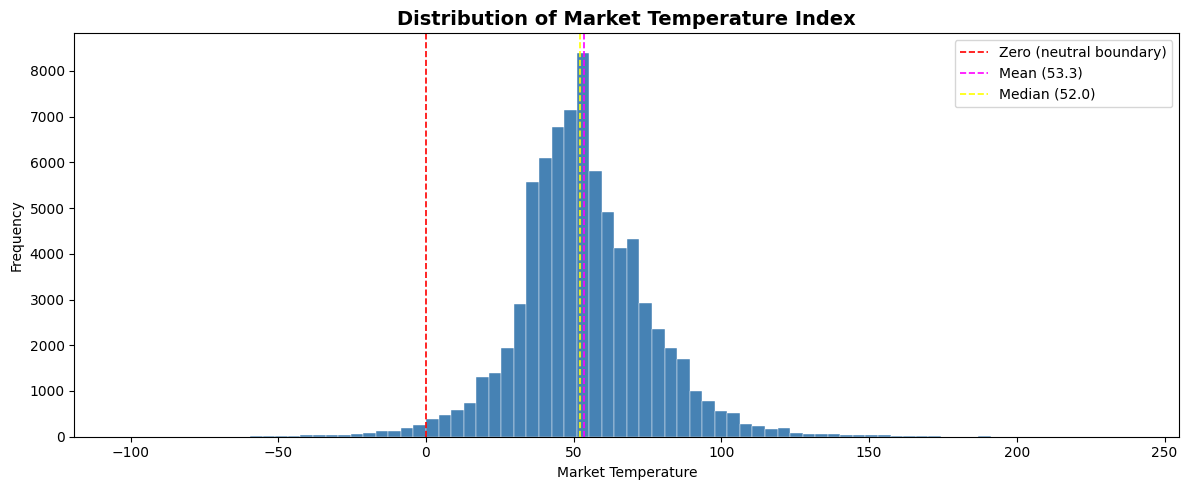

In [131]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_market_temp_updated['MarketTemperature'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (neutral boundary)')
ax.axvline(df_market_temp_updated['MarketTemperature'].mean(), color='magenta', linestyle='--', linewidth=1.2, label=f"Mean ({df_market_temp_updated['MarketTemperature'].mean():.1f})")
ax.axvline(df_market_temp_updated['MarketTemperature'].median(), color='yellow', linestyle='--', linewidth=1.2, label=f"Median ({df_market_temp_updated['MarketTemperature'].median():.1f})")

ax.set_title('Distribution of Market Temperature Index', fontsize=14, weight='bold')
ax.set_xlabel('Market Temperature')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## Descriptive Statistics for Median Sale Price

The median sale price ranges from $24,500 to $1,767,500: this is a huge gap in US housing markets.  — an enormous spread reflecting the diversity of US housing markets. 

The mean ($185,565) is notably higher than the median(50%) ($151,928), this confirn the right-skewed distribution we can see also in the histogram. 

The standard deviation of $120,455 is very high relative to the mean, indicating that price levels vary dramatically across regions.

In [132]:
df_sale_price_updated.describe()

,RegionID,SizeRank,MedianSalePrice
count,143313.000000,143313.000000,1.433130e+05
mean,415663.527349,381.661992,1.855648e+05
std,88602.896386,234.345697,1.204553e+05
min,102001.000000,0.000000,2.450000e+04
25%,394539.000000,181.000000,1.150000e+05
50%,394795.000000,367.000000,1.519280e+05
75%,395046.000000,570.000000,2.150000e+05
max,845172.000000,916.000000,1.767500e+06


### Distribution of Median Sale Price Index

Strongly right-skewed distribution: most prices clustareer below $250k, but a long tail extends to $1.75M+

Mean ($185k) is significantly higher than median ($152k): this means that most markets are actually cheaper than the mean suggests, but a minority of very expensive markets (like big citites' markets) are pulling the average up.

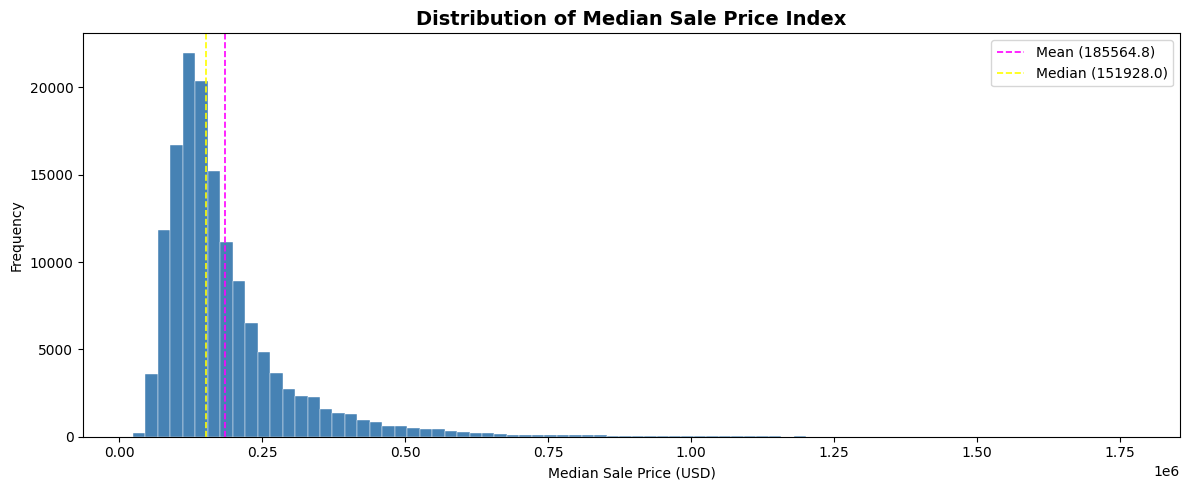

In [133]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_sale_price_updated['MedianSalePrice'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)


ax.axvline(df_sale_price_updated['MedianSalePrice'].mean(), color='magenta', linestyle='--', linewidth=1.2, label=f"Mean ({df_sale_price_updated['MedianSalePrice'].mean():.1f})")
ax.axvline(df_sale_price_updated['MedianSalePrice'].median(), color='yellow', linestyle='--', linewidth=1.2, label=f"Median ({df_sale_price_updated['MedianSalePrice'].median():.1f})")

ax.set_title('Distribution of Median Sale Price Index', fontsize=14, weight='bold')
ax.set_xlabel('Median Sale Price (USD)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## US ANALYSIS ONLY

In [134]:
us_temp = df_market_temp_updated[
    (df_market_temp_updated['RegionName'] == 'United States') & 
    (df_market_temp_updated['RegionType'] == 'country')
]

In [135]:
us_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-02-28,102001,0,United States,country,US,50.0
2018-03-31,102001,0,United States,country,US,52.0
2018-04-30,102001,0,United States,country,US,54.0
2018-05-31,102001,0,United States,country,US,55.0
...,...,...,...,...,...,...
2024-07-31,102001,0,United States,country,US,55.0
2024-08-31,102001,0,United States,country,US,53.0
2024-09-30,102001,0,United States,country,US,52.0


The market temperature index started around ~50 in 2018, but after 2020 it started to rise rapidly most likely because of COVID19 and hit the peak  in early 2022 <br> 
-> we know that a higher temperature means that the market is more favourable for sellers.  <br>
From there the temperature fell rapidly, and by late 2024 it was back to ~50. The post-2022 cooldown lines up perfectly with rising interest rates pricing many buyers out of the market.

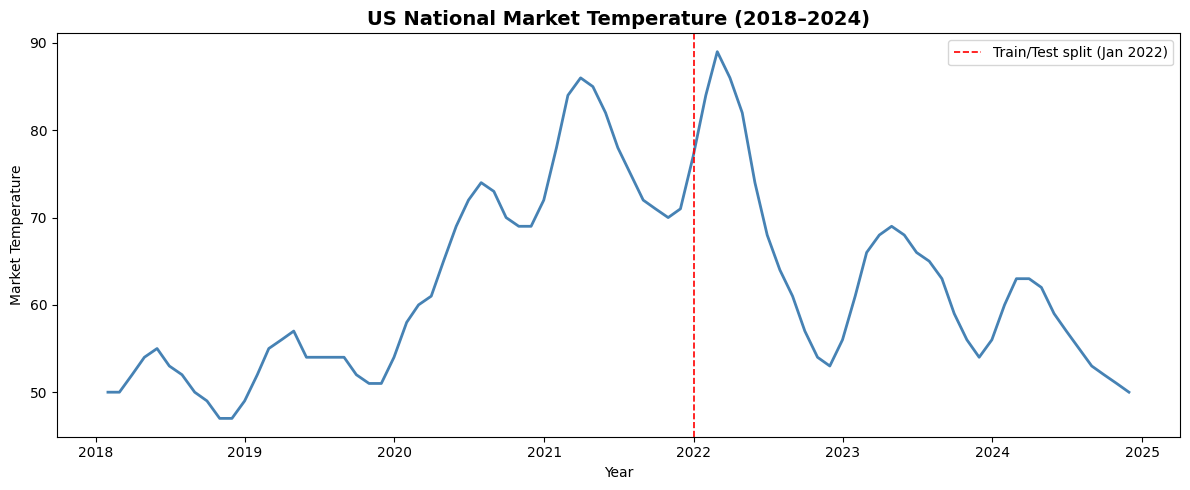

In [136]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(us_temp.index, us_temp['MarketTemperature'], color='steelblue', linewidth=2)

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', linewidth=1.2, label='Train/Test split (Jan 2022)')

ax.set_title('US National Market Temperature (2018–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Market Temperature')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [137]:
us_price = df_sale_price_updated[
    (df_sale_price_updated['RegionName'] == 'United States') & 
    (df_sale_price_updated['RegionType'] == 'country')
]

In [138]:
us_price

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,US,170922.0
2008-03-31,102001,0,United States,country,US,175612.0
2008-04-30,102001,0,United States,country,US,177500.0
2008-05-31,102001,0,United States,country,US,180000.0
2008-06-30,102001,0,United States,country,US,185000.0
...,...,...,...,...,...,...
2024-06-30,102001,0,United States,country,US,369000.0
2024-07-31,102001,0,United States,country,US,361000.0
2024-08-31,102001,0,United States,country,US,360000.0


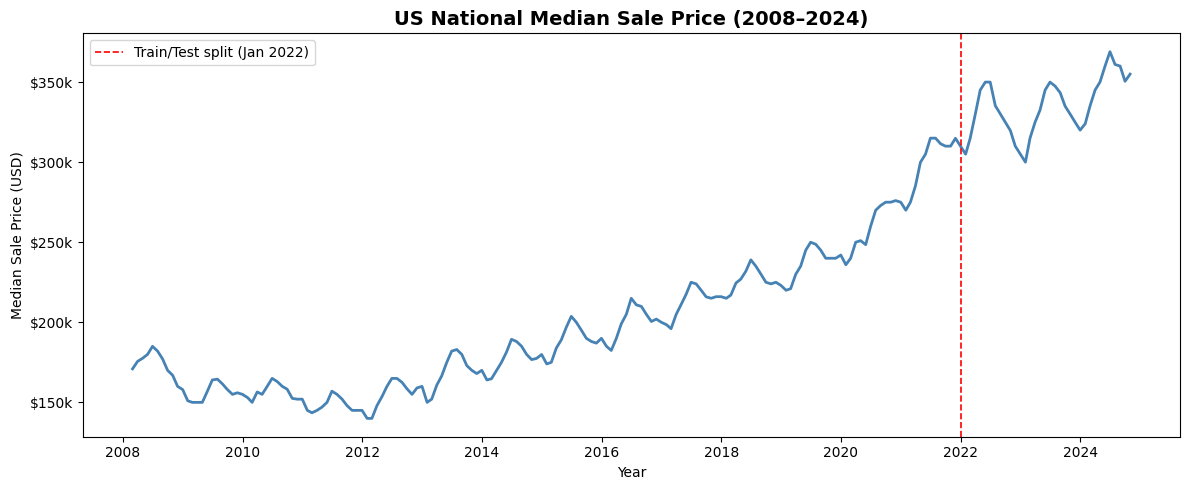

In [139]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(us_price.index, us_price['MedianSalePrice'], color='steelblue', linewidth=2)

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', linewidth=1.2, label='Train/Test split (Jan 2022)')

ax.set_title('US National Median Sale Price (2008–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Sale Price (USD)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

MULTI-LINE CHART

CA is clearly the most expensive market, starting at ~$330k in 2008 and reaching $650k+ by 2024. NY and GA start at similar levels (~$130k) but diverge over time. All three follow the same general pattern: post-2008 dip, steady recovery, then a sharp jump around 2020. After 2022, CA and NY flatten while GA keeps climbing.

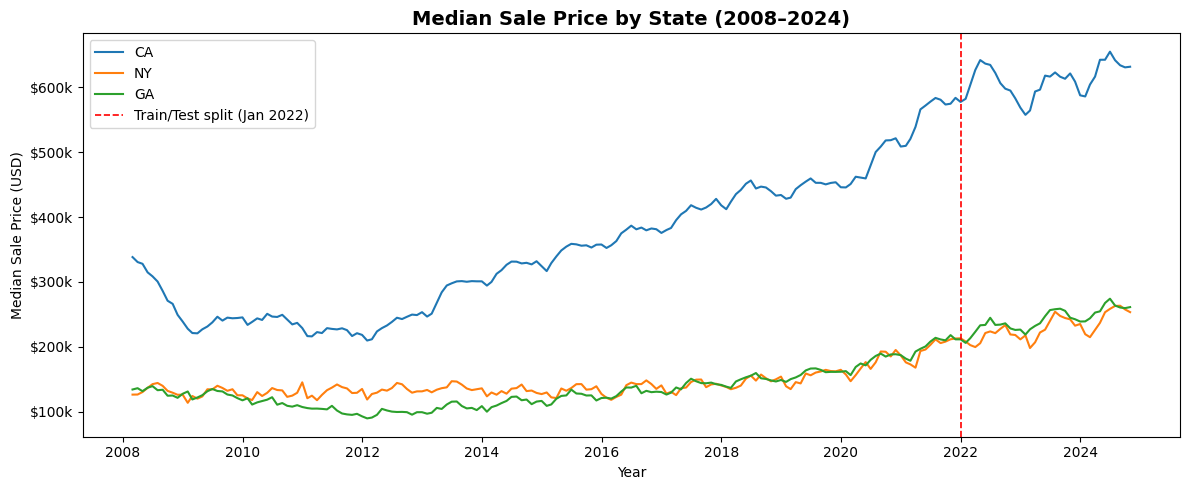

In [140]:
states_to_plot = ['CA', 'NY', 'GA']

# Filter and aggregate
states_price = (df_sale_price_updated[
    df_sale_price_updated['StateName'].isin(states_to_plot)]
    .reset_index()  # bring Date back as a column
    .groupby(['StateName', 'Date'])['MedianSalePrice']
    .mean()
    .reset_index()
    .set_index('Date'))

fig, ax = plt.subplots(figsize=(12, 5))

for state in states_to_plot:
    subset = states_price[states_price['StateName'] == state]
    ax.plot(subset.index, subset['MedianSalePrice'], linewidth=1.5, label=state)

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', linewidth=1.2, label='Train/Test split (Jan 2022)')
ax.set_title('Median Sale Price by State (2008–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Sale Price (USD)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

## HEATMAP CORRELATION

The heatmap all over states is very crowded and difficult to analyse in detail. However, it confirms the general national trend: median sale prices have increased across virtually all states over time, with the most visible acceleration occurring after 2020.

To examine clearly the regional differences a more focused version comparing only the 5 selected states will be presented in the next section. 

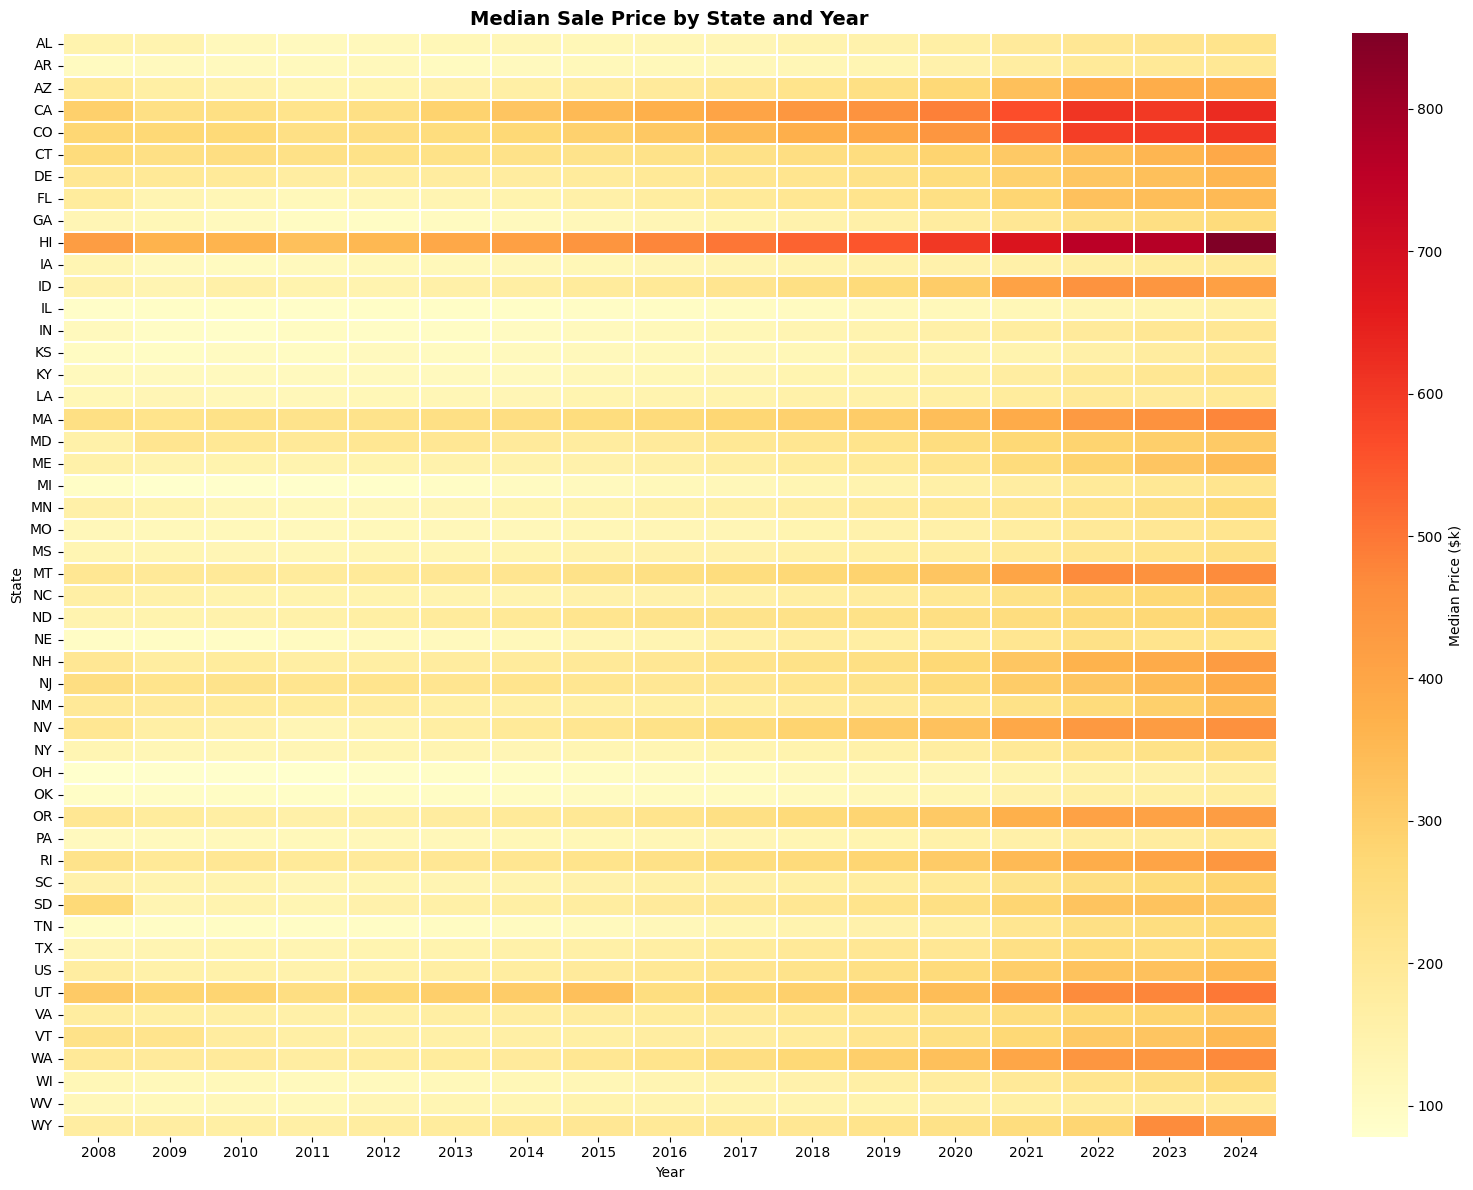

In [141]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Pivot: states as rows, years as columns, mean price as values
heatmap_data = (df_sale_price_updated
                .reset_index()
                .assign(Year=lambda x: x['Date'].dt.year)
                .groupby(['StateName', 'Year'])['MedianSalePrice']
                .mean()
                .unstack('Year'))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(heatmap_data/1000, cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Median Price ($k)'})
ax.set_title('Median Sale Price by State and Year', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

## FREQUENCY ANALYSIS

### Power Spectral Density

The PSD on raw data, as we can see above, shows continuously increasing power toward longer periods, with no identifiable peak.<br> This means that there is a strong upward trend and it dominates the frequency spectrum and makes it impossible to detect any shorter cycles like annual seasonality. <br>
To solve this problem we should detrend the data before proceeding with frequency analysis. 

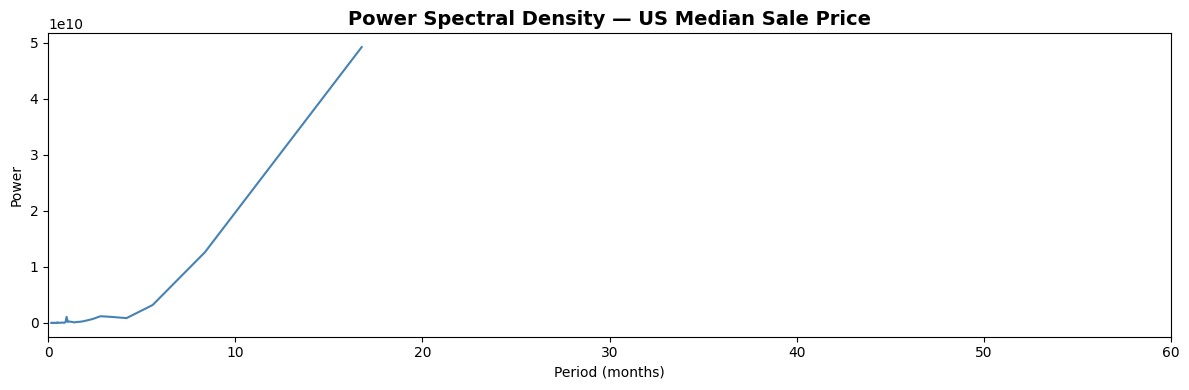

In [142]:
from scipy import signal

# Use the US national price series, drop NaN
us_values = us_price['MedianSalePrice'].dropna().values

# Compute periodogram (sampling frequency = 12 per year since monthly data)
freqs, psd = signal.periodogram(us_values, fs=12)

# Convert frequency to period in months
periods = 1 / freqs[1:]  # skip zero frequency
psd = psd[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, psd, color='steelblue', linewidth=1.5)
ax.set_title('Power Spectral Density — US Median Sale Price', fontsize=14, weight='bold')
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power')
ax.set_xlim(0, 60)  # focus on periods up to 5 years
plt.tight_layout()
plt.show()

### Detrending data -> *np.diff()*

In [143]:
import numpy as np
from scipy import signal

us_values = us_price['MedianSalePrice'].dropna().values

# Difference the series to remove the long-term trend
us_values_diff = np.diff(us_values)  

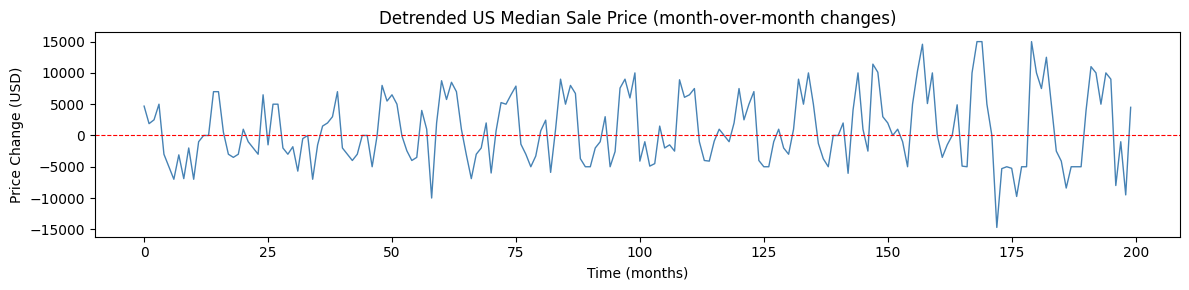

In [144]:
# plot detrended data
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(us_values_diff, color='steelblue', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Detrended US Median Sale Price (month-over-month changes)')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Price Change (USD)')
plt.tight_layout()
plt.show()

### PSD on detrended data

From the plot we see that there are no clear peak at periods 6 or 12, means that there is no semi-annual or annual seasonality at the national aggregate US level. <br>
Since we check it on average prices across all US regions this result is expected. Because maybe some states have peak prices in summer, <br> others have different patterns, and when we combine them all into one national number they cancel each other out. <br>
Doing individual explaration over different states can show more clear seasonality. -> step 3 and 5 <br>



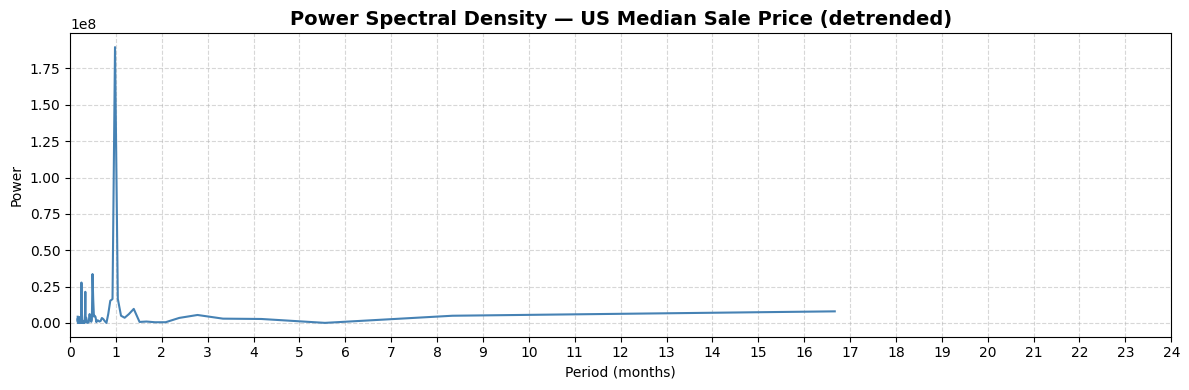

In [145]:
# Compute periodogram
freqs, psd = signal.periodogram(us_values_diff, fs=12)

# Convert frequency to period in months
periods = 1 / freqs[1:]     # skip freq=0 to avoid division by zero
psd = psd[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, psd, color='steelblue', linewidth=1.5)
ax.set_title('Power Spectral Density — US Median Sale Price (detrended)', fontsize=14, weight='bold')
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 1))  
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### ACF Autocorrelation Function -> "How correlated is the series with itself at different time lags?"

Looking at the plot we can see some short-term autocorrelation at lag 1-4, but no clear seasonality at lag 12 which is correlated what we saw in PSD -> absence of strong annual seasonality at the national level

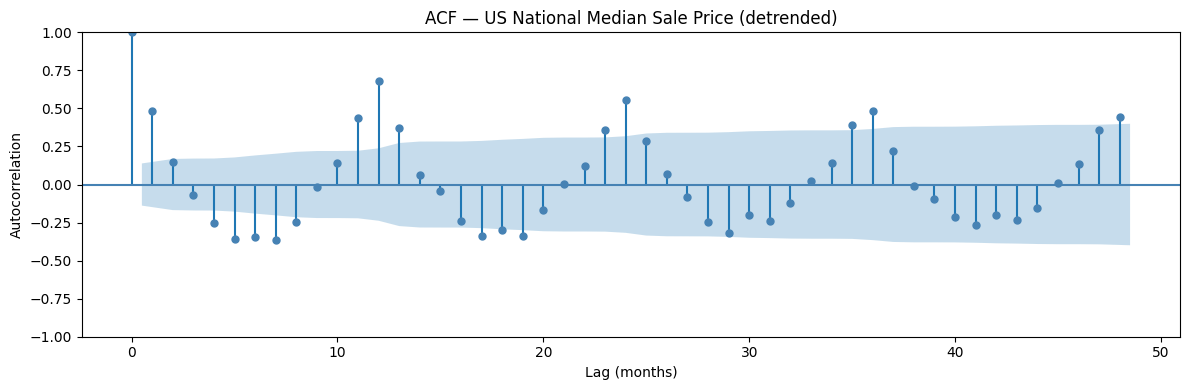

In [146]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(us_values_diff, 
         lags=48,
         ax=ax,
         color='steelblue',
         title='ACF — US National Median Sale Price (detrended)')

ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

# 3. Focusing on 5 different US states , describing the time series patterns (visually and numerically)

In [ ]:
# Market heat index
market_temp_train = df_market_temp_updated[df_market_temp_updated.index < '2022-01-01']
market_temp_test  = df_market_temp_updated[df_market_temp_updated.index >= '2022-01-01']

# Median sale price
median_sale_train = df_sale_price_updated[df_sale_price_updated.index < '2022-01-01']
median_sale_test  = df_sale_price_updated[df_sale_price_updated.index >= '2022-01-01']



In [168]:
selected_states = {
    'NC': 'North Carolina',
    'CA': 'California',
    'WA': 'Washington',
    'TX': 'Texas',
    'PA': 'Pennsylvania'
}

## Time series plot for each state

Observation from plots below: 
- We can see that some states have expensive markets, such as : Washington and California, and others  are cheaper than those. Indeed, we can see that the NC, TX and PA have similar prices. 
- All 5 states share the same story: flat/slow 2008–2016, steady growth 2016–2020, sharp acceleration 2020–2022, then some leveling off post split.
- California and Washington show the smoothest, most consistent upward trends.
- Texas and North Carolina are noisier.
- Pennsylvania shows the most visible regular oscillations, hinting at a seasonal pattern.
- After 2022: 
    - North Carolina and Texas continue climbing even after the split. 
    - California and Washington flatten noticeably. 
    - Pennsylvania keeps its oscillating pattern but at a higher price level. 

In [ ]:
# filter train and test sets for selected states only — one line each
states_train = {state: median_sale_train[median_sale_train['StateName'] == state]
                .groupby(level=0)['MedianSalePrice'].mean()
                for state in selected_states}

states_test = {state: median_sale_test[median_sale_test['StateName'] == state]
               .groupby(level=0)['MedianSalePrice'].mean()
               for state in selected_states}

In [170]:
states_train

{'NC': Date
 2008-02-29    171132.352941
 2008-03-31    163661.764706
 2008-04-30    163941.176471
 2008-05-31    178821.088235
 2008-06-30    173301.470588
                   ...      
 2021-08-31    238889.705882
 2021-09-30    240058.823529
 2021-10-31    237954.411765
 2021-11-30    235941.176471
 2021-12-31    248461.764706
 Name: MedianSalePrice, Length: 167, dtype: float64,
 'CA': Date
 2008-02-29    338275.000000
 2008-03-31    330591.666667
 2008-04-30    327908.333333
 2008-05-31    314741.666667
 2008-06-30    308600.000000
                   ...      
 2021-08-31    580716.666667
 2021-09-30    573341.666667
 2021-10-31    574583.333333
 2021-11-30    583625.000000
 2021-12-31    577341.666667
 Name: MedianSalePrice, Length: 167, dtype: float64,
 'WA': Date
 2008-02-29    198253.055556
 2008-03-31    194184.722222
 2008-04-30    193790.500000
 2008-05-31    198018.000000
 2008-06-30    201360.222222
                   ...      
 2021-08-31    419552.777778
 2021-09-30    41

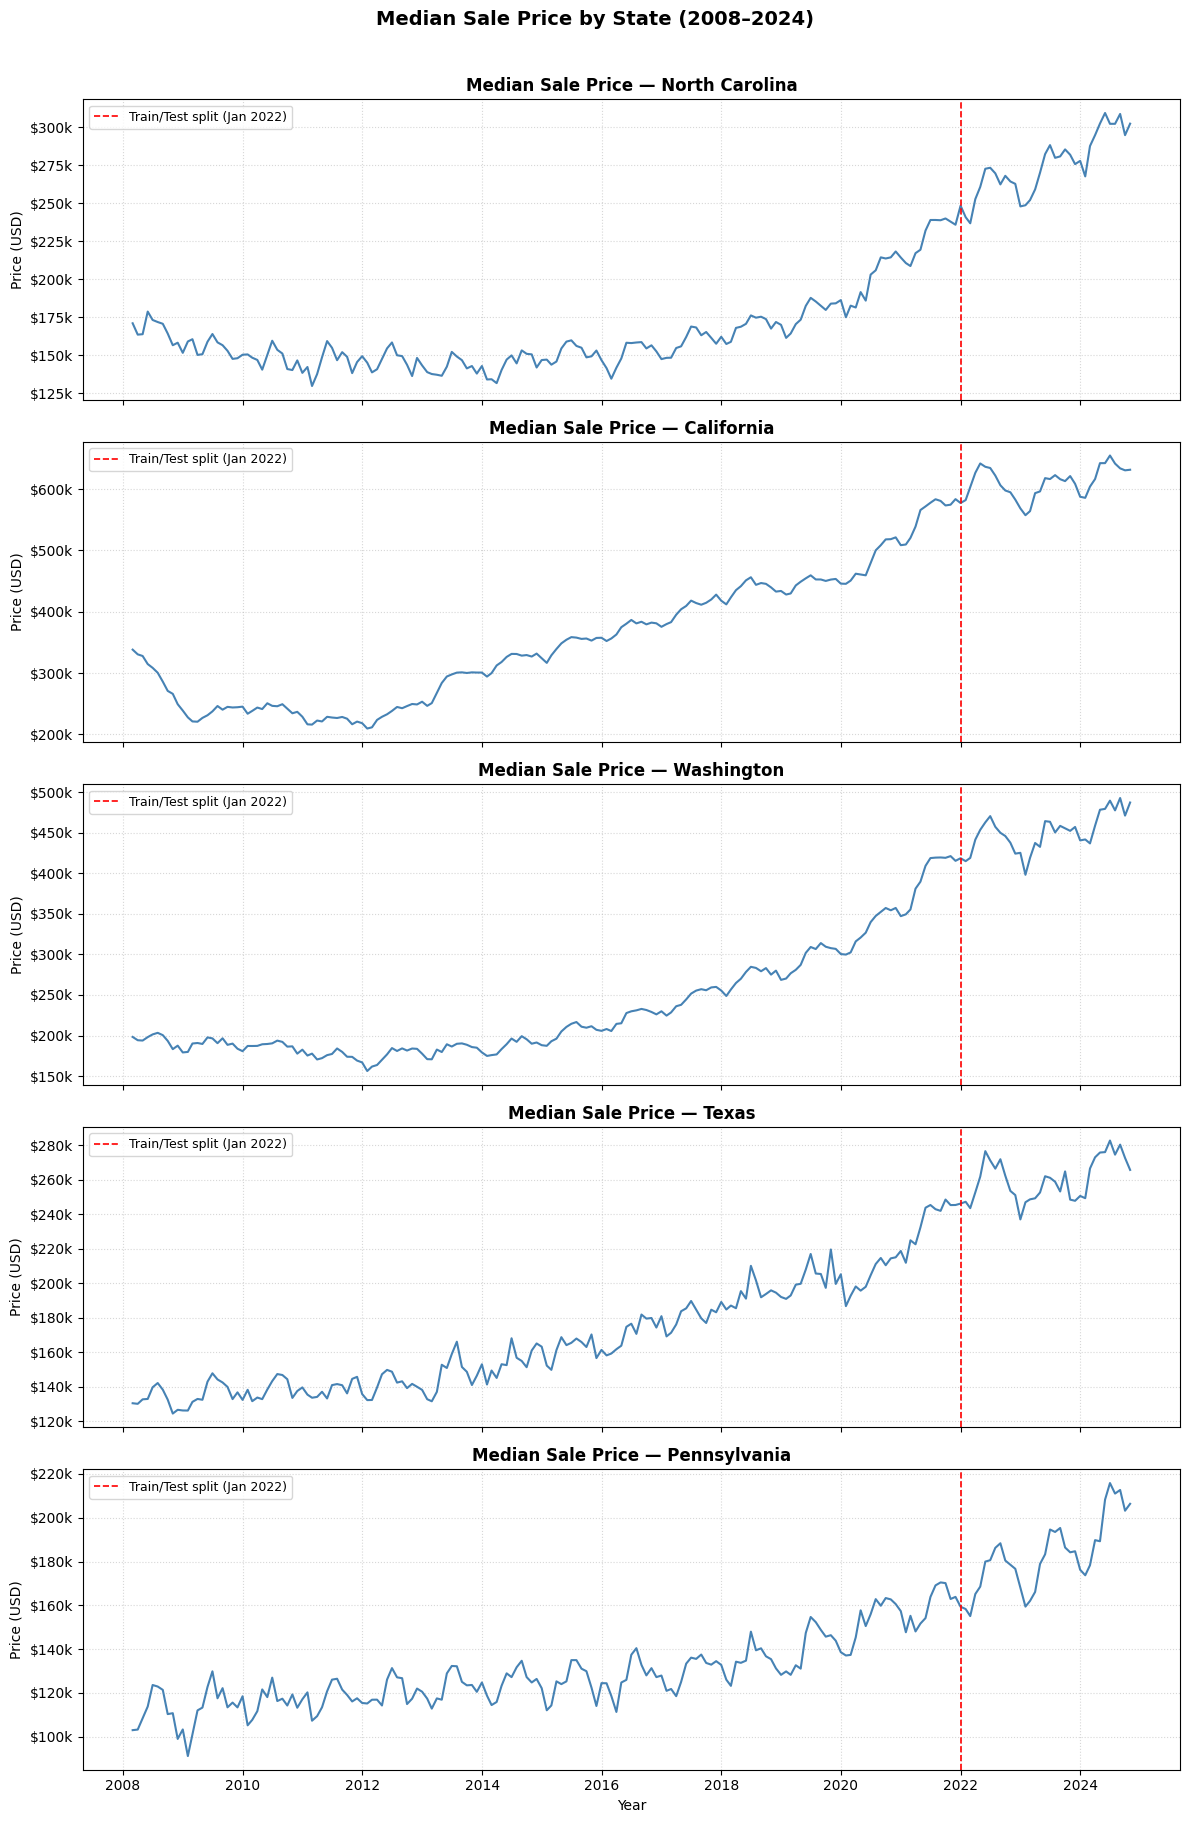

In [176]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for ax, state in zip(axes, selected_states):
    # combine train and test for full picture
    full_series = pd.concat([states_train[state], states_test[state]])
    
    ax.plot(full_series.index, full_series.values, color='steelblue', linewidth=1.5)
    ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', 
               linewidth=1.2, label='Train/Test split (Jan 2022)')
    ax.set_title(f'Median Sale Price — {selected_states[state]}', fontsize=12, weight='bold')
    ax.set_ylabel('Price (USD)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Year')
plt.suptitle('Median Sale Price by State (2008–2024)', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Check lags for each state

I decided to plot 4 lags: 
- lag1: to see if the next month predictable from this month;
- lag3: to see quarterly relationship
- Lag6: semi-annual correlation
- Lag12: annual correlation to see if this year's price correlate with same month last year

Observations: 
- All states show a clear linear pattern at every lag, confirming that the data is not random and that current prices are strongly predictable from past prices. 
- Lag1: tightest across all states, means that last month's price is an almost perfect predictor of this month's price
- When lag increase the scatter is wider, we can see that the diagonal pattern loosens progressively from lag 1 to lag 12, this means that the further back we look,<br>the less precise the relationship. But,still clearly linear though, never a random cloud.
- I also want to precise that Pennsylvania shows the most spread at lag 6 and lag 12, the points are more dispersed around the diagonal compared to other states,<br>
 which highlights at a seasonal cycle disrupting the simple lag relationship. We can confirm that this behaviour is consistent with the oscillating pattern visible in the time series plot.

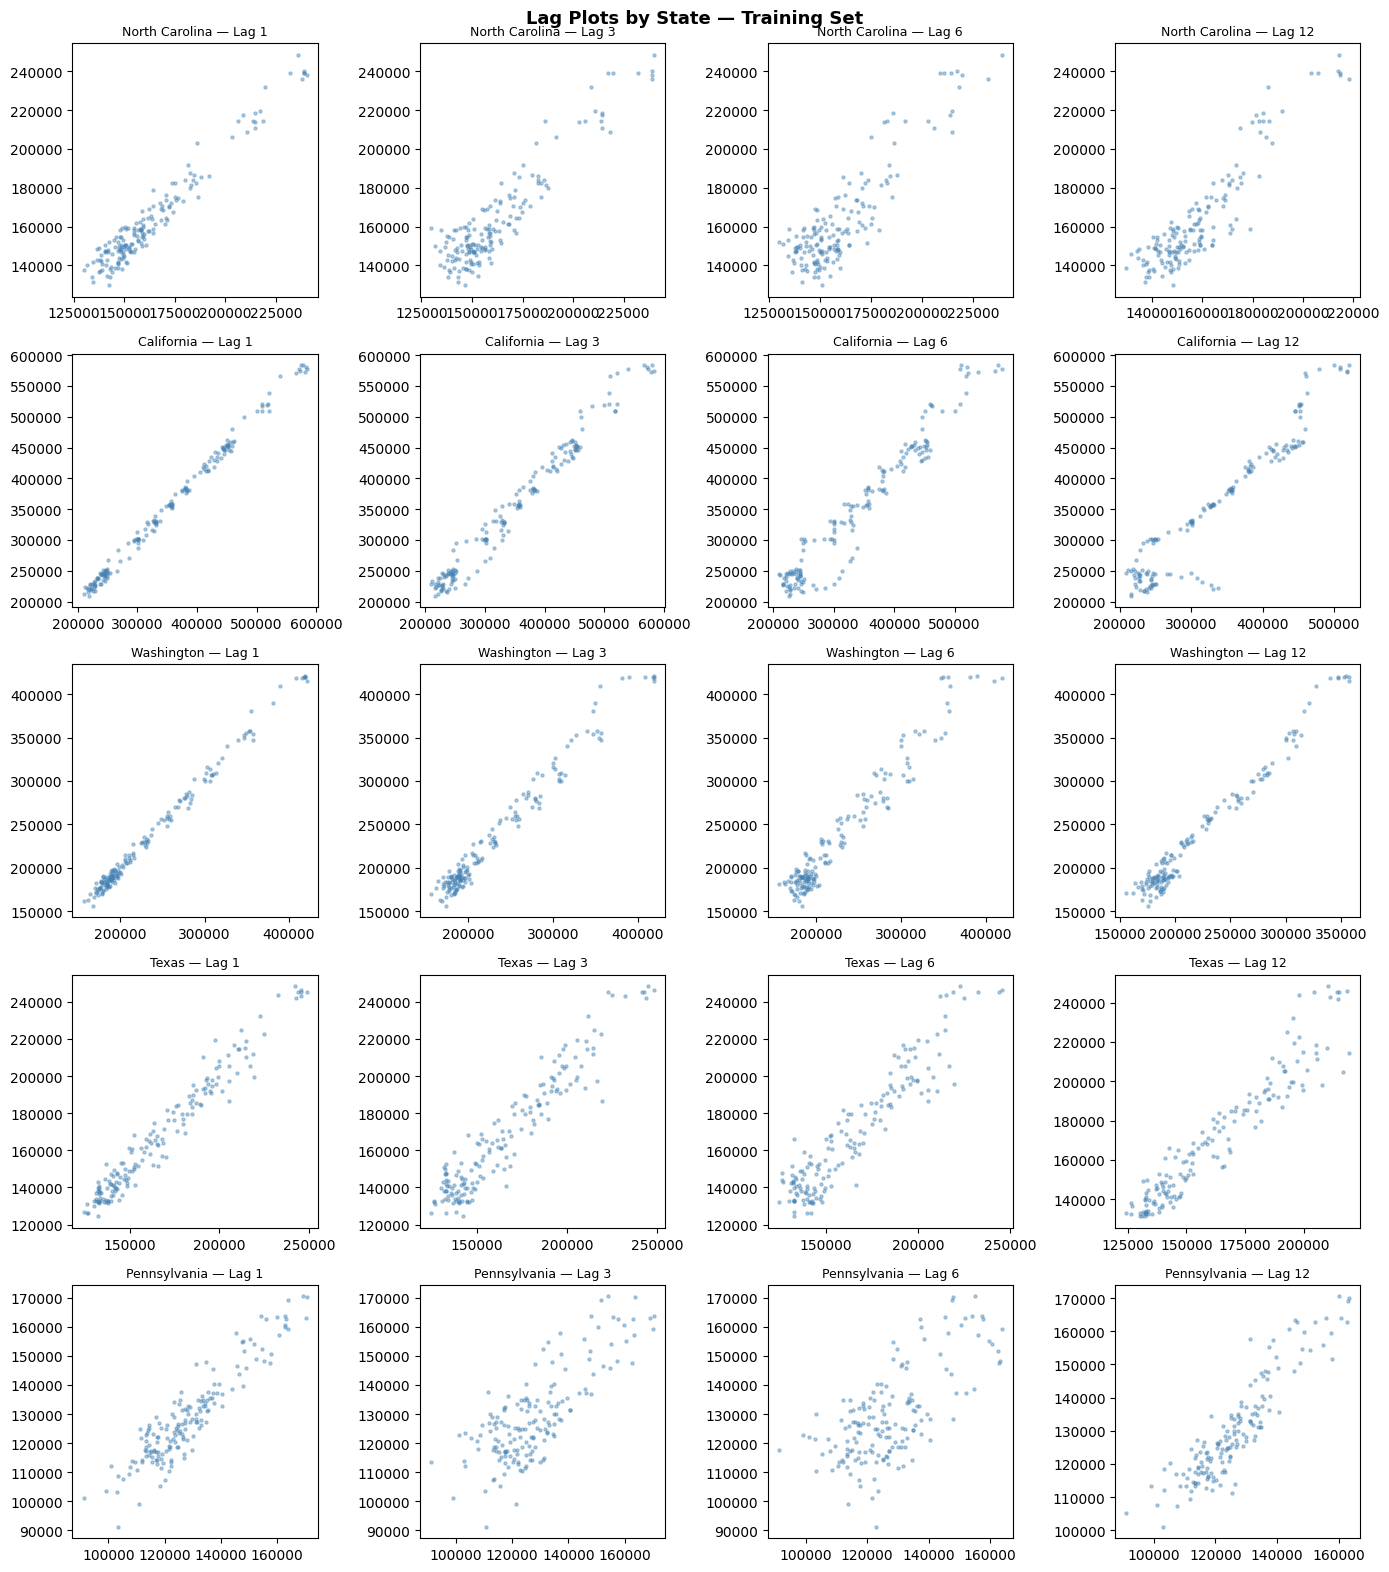

In [173]:
from pandas.plotting import lag_plot

lags_to_plot = [1, 3, 6, 12]

fig, axes = plt.subplots(5, 4, figsize=(14, 16))

for row, (state, full_name) in enumerate(selected_states.items()):
    for col, lag in enumerate(lags_to_plot):
        lag_plot(states_train[state], lag=lag, ax=axes[row, col],
                 c='steelblue', alpha=0.4, s=5)
        axes[row, col].set_title(f'{full_name} — Lag {lag}', fontsize=9)
        axes[row, col].set_xlabel('')
        axes[row, col].set_ylabel('')

plt.suptitle('Lag Plots by State — Training Set', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## Check ACF+PACF

**ACF** of all 5 states:
All show a slowly and gradually decreasing over 48 lags without ever dropping to zero. This is the classic signature of a non-stationary trending series. <br>
The series has long memory. For example, prices from 2 years ago are still correlated with today's prices, simply because of the persistent upward trend.
There are not clear peaks at lag 12, 24, 36 which confirms no strong annual seasonality at the state level either, consistent with what found nationally in Step 2.

**PACF** of all 5 states: 
All show a large spike at lag 1, then an immediate drop to near zero for all subsequent lags. This is the classic AR(1) signature, <br> only the immediately preceding month has a direct effect on the current price. Everything else is indirect.

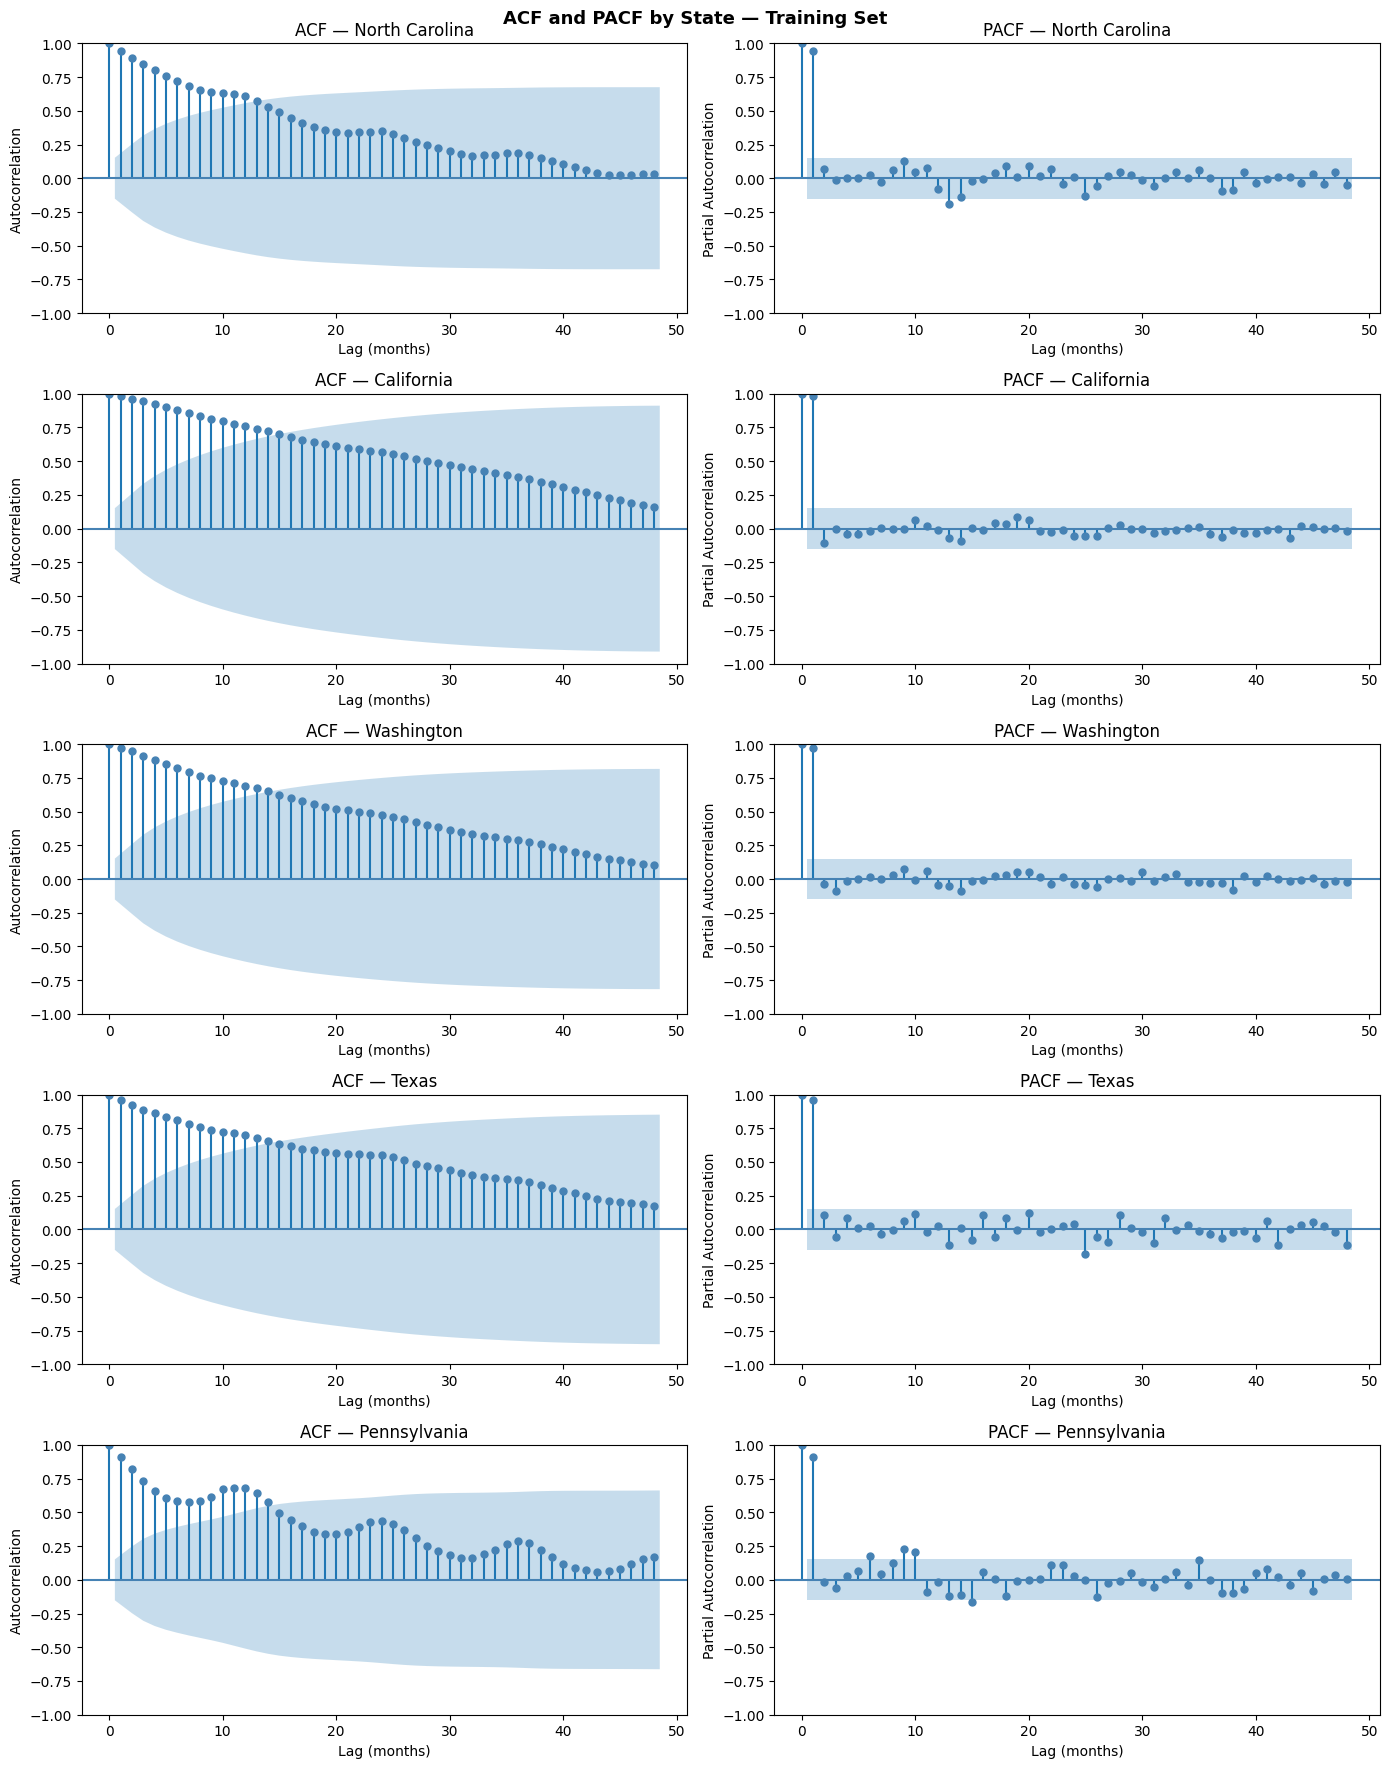

In [179]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for row, (state, full_name) in enumerate(selected_states.items()):
    # ACF
    plot_acf(states_train[state], lags=48, ax=axes[row, 0],
             color='steelblue', title=f'ACF — {full_name}')
    axes[row, 0].set_xlabel('Lag (months)')
    axes[row, 0].set_ylabel('Autocorrelation')

    # PACF
    plot_pacf(states_train[state], lags=48, ax=axes[row, 1],
              color='steelblue', title=f'PACF — {full_name}')
    axes[row, 1].set_xlabel('Lag (months)')
    axes[row, 1].set_ylabel('Partial Autocorrelation')

plt.suptitle('ACF and PACF by State — Training Set', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# 4. Is there any associations with the market heat index (considering the common time window)?

# 5. Choosing the appropriate model(s) to forecast the data for the specified period for each selected state/house type. Evaluate the model performance using different metrics. Visualise the results with appropriate graphs.